In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyreadstat import read_sav
from pyreadstat import metadata_container

np.random.seed(42)

In [18]:
df: pd.DataFrame; meta: metadata_container
df, meta = read_sav('data.sav')
df = df.drop('k4_new', axis=1)
print(df.shape)
df.head()

(2695, 22)


,Cреднеспис.числ.работн,k1,k2,k3,k4,k5,k6,k7,k8,k9,k10,k11,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
0,6095.0,0.942380,0.060563,0.678302,-0.161531,0.202055,0.165019,0.399033,0.799019,5.426569,0.209235,1.115922,1.082798,0.655937,4.454819,3.975687,0.892446,1007.536232,0.076738,0.055049,0.034904,5.0
1,255.0,1.980494,0.274382,0.916775,0.624425,0.089377,0.220648,0.000000,0.933519,14.041958,0.215083,1.259382,1.123828,0.705951,10.618881,12.295547,1.157895,357.294118,0.116068,0.059740,0.025647,5.0
2,114.0,0.374160,0.001494,0.085138,-1.504990,0.235739,0.508929,0.888889,0.779049,5.017007,0.096737,0.774586,1.185374,0.123415,0.794785,6.258929,7.875000,36.894737,-0.584879,0.010563,0.000000,5.0
3,365.0,7.859079,0.831978,2.449864,0.875862,0.059439,0.030030,0.011111,0.942010,16.244444,0.876663,1.223284,1.309449,2.804607,48.363889,26.142643,0.540541,33.676983,0.171731,0.496295,0.312415,5.0
4,168.0,1.779376,0.005596,0.883293,0.527853,0.135491,0.886686,0.489796,0.887341,10.558673,0.313389,0.874381,0.994832,0.473041,5.628827,3.125354,0.555241,19.103896,0.064809,0.025726,0.011839,5.0


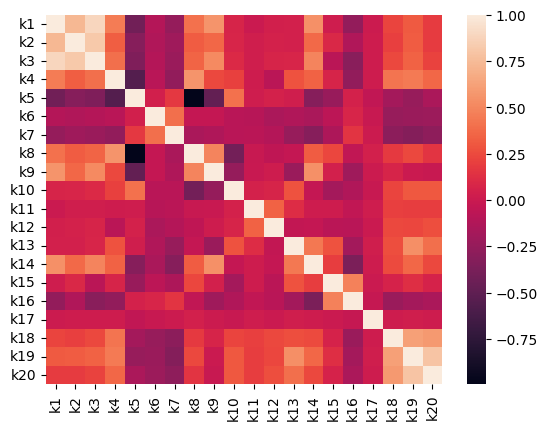

In [19]:
sns.heatmap(df[df.columns[1:-1]].corr())
plt.show()

df = df.drop('k8', axis=1)
NUM_COLS = df.columns[1:-1]

Нахождение выбросов (Isolation forest)

In [20]:
from sklearn.ensemble import IsolationForest

df_train: pd.DataFrame; df_test: pd.DataFrame
print(f"Shape: {df.shape}")

clf = IsolationForest(
    n_estimators=200,           # Больше деревьев = стабильнее
    max_samples='auto',         # Можно попробовать 256, 512, 1024
    contamination='auto',       # или 0.05, или подобрать вручную
    max_features=0.8,           # Используем не все признаки сразу (боремся с шумом)
    bootstrap=False,
    random_state=42
)

clf.fit(df[NUM_COLS])
outliers_train: np.ndarray = clf.predict(df[NUM_COLS])

print(f"Number of outliers in df: {np.abs( outliers_train[outliers_train == -1].sum() )}")

Shape: (2695, 21)
Number of outliers in df: 140


Винсоризация:

In [21]:
outliers_mask = (outliers_train == -1)
percentiles = {}
for col in NUM_COLS:
    p_low: float = df[col][outliers_mask].max()
    p_high = df[col][outliers_mask].min()
    percentiles[col] = (p_low, p_high)

df_clean: pd.DataFrame = df.copy()
for col in NUM_COLS:
    low, high = percentiles[col]
    col_data = df_clean[col][outliers_mask]
    col_data[col_data < low] = low
    col_data[col_data > high] = high
    df_clean.loc[outliers_mask, col] = col_data


Стандартизация:

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(df_clean)

df_array: np.ndarray = scaler.transform(df_clean)
df_stand: pd.DataFrame = pd.DataFrame(df_array,
                                             columns=df_clean.columns,
                                               index=df_clean.index)


Метод главных компонент:

In [ ]:
from sklearn.decomposition import PCA

n_pca_components: int = 6

pca = PCA(n_components=n_pca_components, random_state=42)
pca.fit(df_stand[NUM_COLS])
pca_eigen_values: np.ndarray = pca.explained_variance_
print(f"Eigen values: {pca_eigen_values}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"cumsum of explained variance ratio: {np.cumsum(pca.explained_variance_ratio_)}")
pca_array: np.ndarray = pca.transform(df_stand[NUM_COLS])

print("\nDataframe in principal components space:")
pca_columns: list[str] = ['pca_' + str(i + 1) for i in range(n_pca_components)]
df_pca: pd.DataFrame = pd.DataFrame(pca_array, columns=pca_columns, index=df_stand.index)
print(df_pca.shape)
print(df_pca.head())

Eigen values: [5.5987809  2.9380739  1.75171707 1.57360811 1.20625189 1.13188072]
Explained variance ratio: [0.29456334 0.15457809 0.09216143 0.08279075 0.06346338 0.05955056]
cumsum of explained variance ratio: [0.29456334 0.44914143 0.54130285 0.6240936  0.68755699 0.74710755]

Dataframe in principal components space:
(2695, 6)
      pca_1     pca_2     pca_3     pca_4     pca_5     pca_6
0 -0.798915  0.099392  0.331314  1.092439  0.168986 -0.492496
1  0.717610 -1.618289  0.933601  0.456164  0.297785 -0.540134
2 -8.038094 -3.146846 -1.073733 -0.901458  0.129425  0.132965
3 -8.038094 -3.146846 -1.073733 -0.901458  0.129425  0.132965
4 -0.364809 -0.010250  1.195145  3.364430 -1.558042 -0.639559


In [43]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loadings_df = pd.DataFrame(
    loadings,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df_stand[NUM_COLS].columns
)

print(loadings_df)

          PC1       PC2       PC3       PC4       PC5       PC6
k1   0.668609 -0.545041 -0.081808  0.179272 -0.036090  0.233800
k2   0.486105 -0.526628 -0.068422  0.081062  0.065013  0.491953
k3   0.629471 -0.551764 -0.238268  0.230394  0.004031  0.270061
k4   0.880224  0.189729  0.137784  0.131800 -0.093555  0.003514
k5   0.078861  0.735849 -0.392843  0.010224 -0.047185  0.071844
k6   0.057892  0.309135  0.242228  0.561282 -0.416933 -0.048810
k7  -0.111005  0.405826  0.216780  0.603897 -0.222758 -0.018097
k9   0.397338 -0.561047  0.359009  0.280149  0.028568 -0.304655
k10  0.326701  0.364096 -0.620103 -0.056936 -0.191278  0.290379
k11  0.457265  0.262136  0.022711 -0.002046  0.516063 -0.193406
k12  0.445157  0.246807 -0.040418  0.069639  0.656531 -0.109517
k13  0.562184  0.168971 -0.193255 -0.524041 -0.359663 -0.175415
k14  0.616353 -0.383142 -0.006574 -0.236781 -0.273436 -0.409520
k15  0.282935  0.014821  0.641769 -0.548671 -0.141361  0.154904
k16 -0.073480  0.387444  0.638173 -0.183

In [50]:
from factor_analyzer import Rotator

rotator = Rotator(method='quartimax')
rotated_loadings = rotator.fit_transform(loadings)
df_rotated_loadings = pd.DataFrame(
    rotated_loadings,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df_stand[NUM_COLS].columns
)
print(df_rotated_loadings[df_rotated_loadings >= 0.5])

          PC1  PC2       PC3       PC4       PC5       PC6
k1        NaN  NaN       NaN       NaN       NaN       NaN
k2        NaN  NaN       NaN       NaN       NaN       NaN
k3        NaN  NaN       NaN       NaN       NaN       NaN
k4   0.863756  NaN       NaN       NaN       NaN       NaN
k5        NaN  NaN       NaN       NaN       NaN  0.679635
k6        NaN  NaN       NaN  0.779233       NaN       NaN
k7        NaN  NaN       NaN  0.732682       NaN       NaN
k9        NaN  NaN       NaN       NaN       NaN       NaN
k10       NaN  NaN       NaN       NaN       NaN  0.765220
k11  0.603028  NaN       NaN       NaN       NaN       NaN
k12  0.582977  NaN       NaN       NaN  0.506409       NaN
k13  0.525853  NaN       NaN       NaN       NaN       NaN
k14       NaN  NaN       NaN       NaN       NaN       NaN
k15       NaN  NaN  0.747633       NaN       NaN       NaN
k16       NaN  NaN  0.874521       NaN       NaN       NaN
k17       NaN  NaN       NaN       NaN       NaN       N